# LOAD LIBRARIES

In [1]:

import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
from scipy.stats import lognorm 
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet

In [2]:
# Project settings (dataset period, data paths): see src/config.py
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import DATA_DIR, PERIOD_START, PERIOD_END, select_period
print(f"Dataset period: {PERIOD_START} to {PERIOD_END} (CET, UTC+1)")

Dataset period: 2023-10-17 00:00:00 to 2024-08-23 00:00:00 (CET, UTC+1)


Custom plotting function

In [3]:
def plot_data_grid(indat, ncols=3):
    vars = indat.columns
    nrows = (len(vars) + ncols - 1) // ncols  # Calculate the number of rows needed
    relative_markersize = max(1, 10 / len(vars))  # Scale marker size inversely to the number of plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), constrained_layout=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    for ax, var in zip(axes, vars):
        ax.plot(indat[var], marker='o', markersize=relative_markersize, label=var)
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    # Remove any unused subplots
    for ax in axes[len(vars):]:
        fig.delaxes(ax)
    
    plt.show()

# READ DATA

## FLUXES

Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.298 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


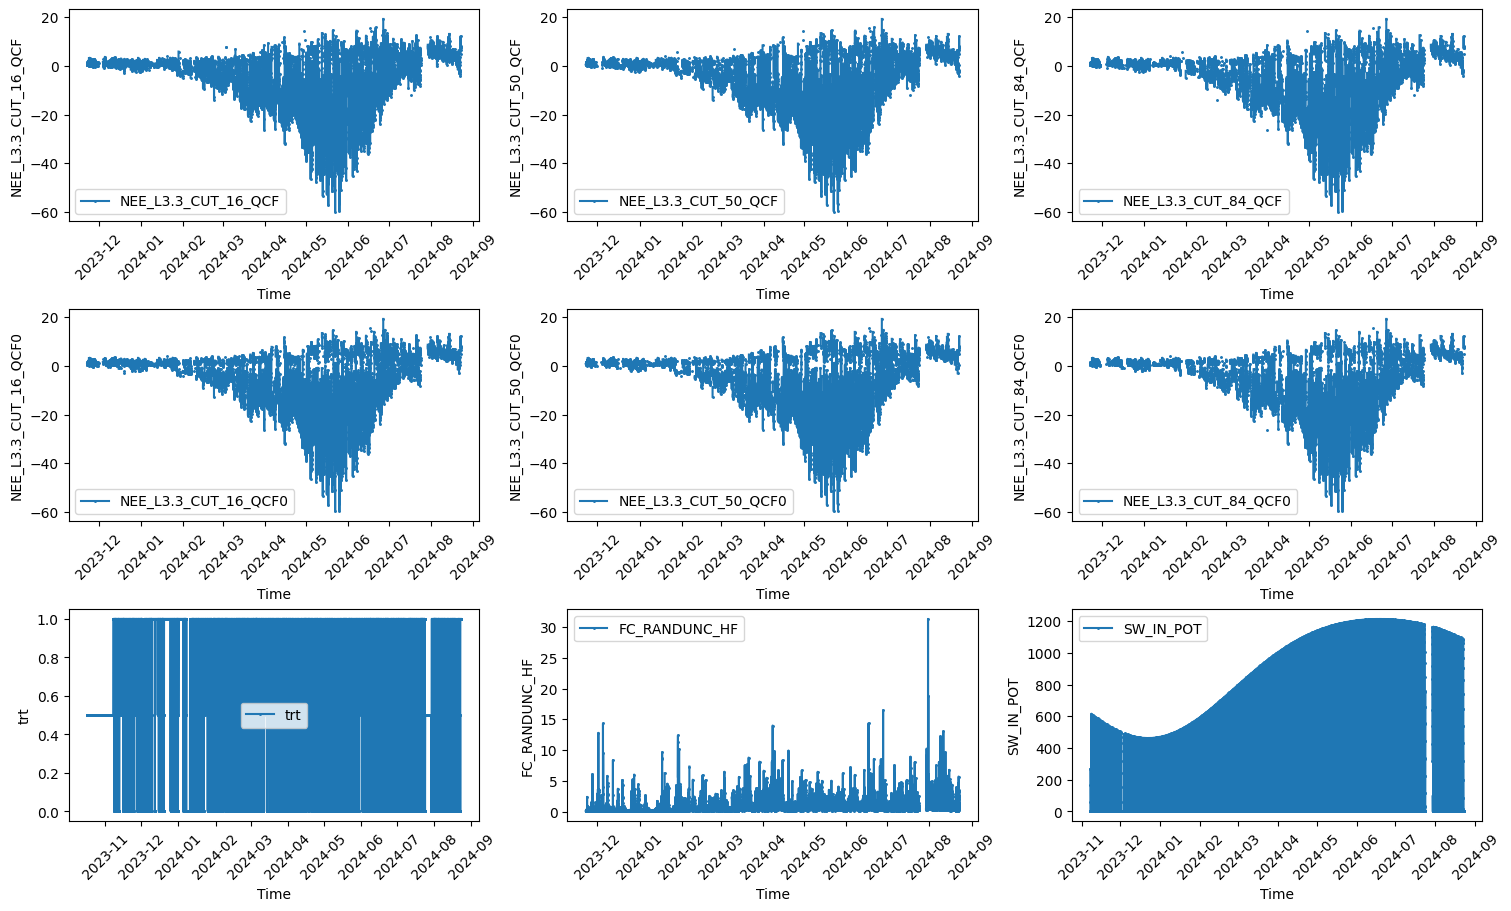

,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-10-16 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN
2023-10-16 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.48319,0.0
2024-08-22 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.96792,0.0
2024-08-22 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.14515,0.0


In [4]:
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")

nee_fluxes = [c for c in fluxes.columns if c.startswith('NEE_L3.3_CUT')]

cols = nee_fluxes + ['parcel', 'parcel_certainty', 'trt', 'FC_RANDUNC_HF'] + ['SW_IN_POT']

fluxes = fluxes[cols].copy()

# plots
indat = fluxes.drop(columns=['parcel', 'parcel_certainty'])
plot_data_grid(indat, ncols=3)

# show data
fluxes

## METEO

Bulk density data used for WFPS calculation was measured on May 2025.
See file CH-TAN_20250520_soil_bulk_density.xlsx

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.151 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


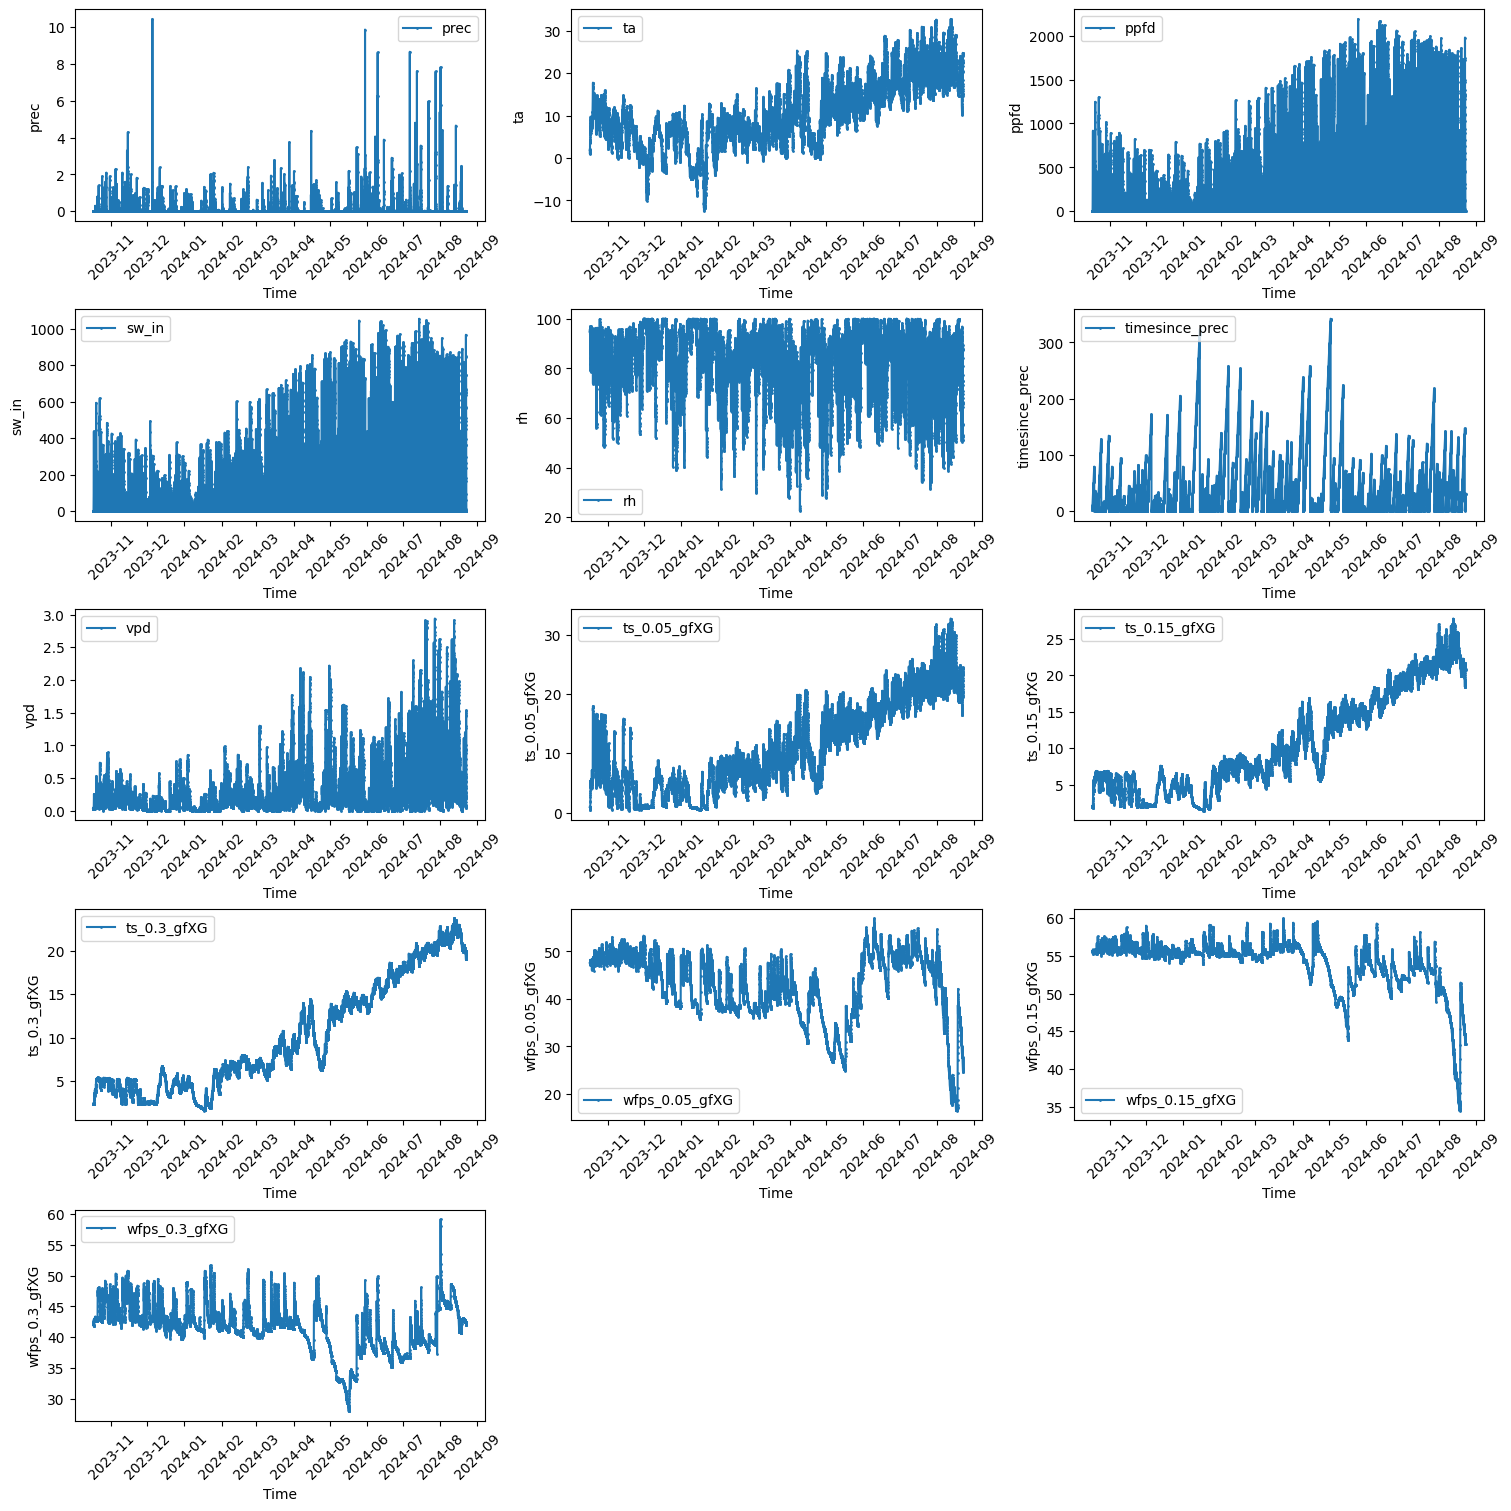

,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2023-10-17 00:15:00,0.0,1.966667,0.0,0.0,94.800000,1,0.036616,0.960360,1.982974,2.418947,47.552073,55.677345,42.117418
2023-10-17 00:45:00,0.0,1.966667,0.0,0.0,95.100000,2,0.034503,0.960360,1.982974,2.418947,47.503224,55.673328,42.199482
2023-10-17 01:15:00,0.0,1.566667,0.0,0.0,94.966667,3,0.034438,0.977859,1.979185,2.385123,47.570344,55.690924,42.228453
2023-10-17 01:45:00,0.0,1.266667,0.0,0.0,94.366667,4,0.037719,0.958305,1.983747,2.386804,47.570344,55.687167,42.228453
2023-10-17 02:15:00,0.0,1.400000,0.0,0.0,95.600000,5,0.029746,0.888469,1.983107,2.375158,47.552213,55.664477,42.363205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,0.0,15.870000,0.0,0.0,84.016666,27,0.288649,20.472592,21.285185,20.000000,24.908687,43.334252,42.081014
2024-08-22 22:15:00,0.0,15.160000,0.0,0.0,87.603334,28,0.213907,20.140000,21.171852,20.000000,24.819067,43.334760,42.085077
2024-08-22 22:45:00,0.0,15.100000,0.0,0.0,87.666666,29,0.211994,19.875554,21.030370,20.000000,24.747323,43.301952,42.075398


In [5]:
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")

cols =['prec',
       'ta',
       'ppfd',
       'sw_in',
       'rh',
       'timesince_prec', 
       'vpd',
       'ts_0.05_gfXG',
       'ts_0.15_gfXG', 
       'ts_0.3_gfXG',
       'swc_0.05_gfXG',
       'swc_0.15_gfXG',
       'swc_0.3_gfXG'
       ]

meteo = meteo[cols]

# Calculate WFPS from SWC using formula with bulk density and particle density
bulk_density = {
    '0.05': 1.1, 
    '0.15': 1.1, 
    '0.3': 1.2, 
}

# Standard particle density since it was not measured
particle_density = 2.65

# Iterate over SWC columns and compute WFPS
swc_cols = [col for col in meteo if col.startswith('swc_')]
for col in swc_cols:
    new_name = col.replace('swc', 'wfps')
    for depth, bd in bulk_density.items():
        if depth in col:
            # calculate wfps for current depth
            wfps = meteo[col] / (1 - (bd / particle_density)) # no need to multiply by 100 because swc is in percent
            meteo[new_name] = wfps
            break

# Now we can remove all the swc columns from which we calculated wfps
meteo.drop(columns=swc_cols, inplace=True)

# plots
plot_data_grid(meteo, ncols=3)

# show data
meteo

## MANAGEMENT

Loaded .parquet file ../../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet (0.054 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


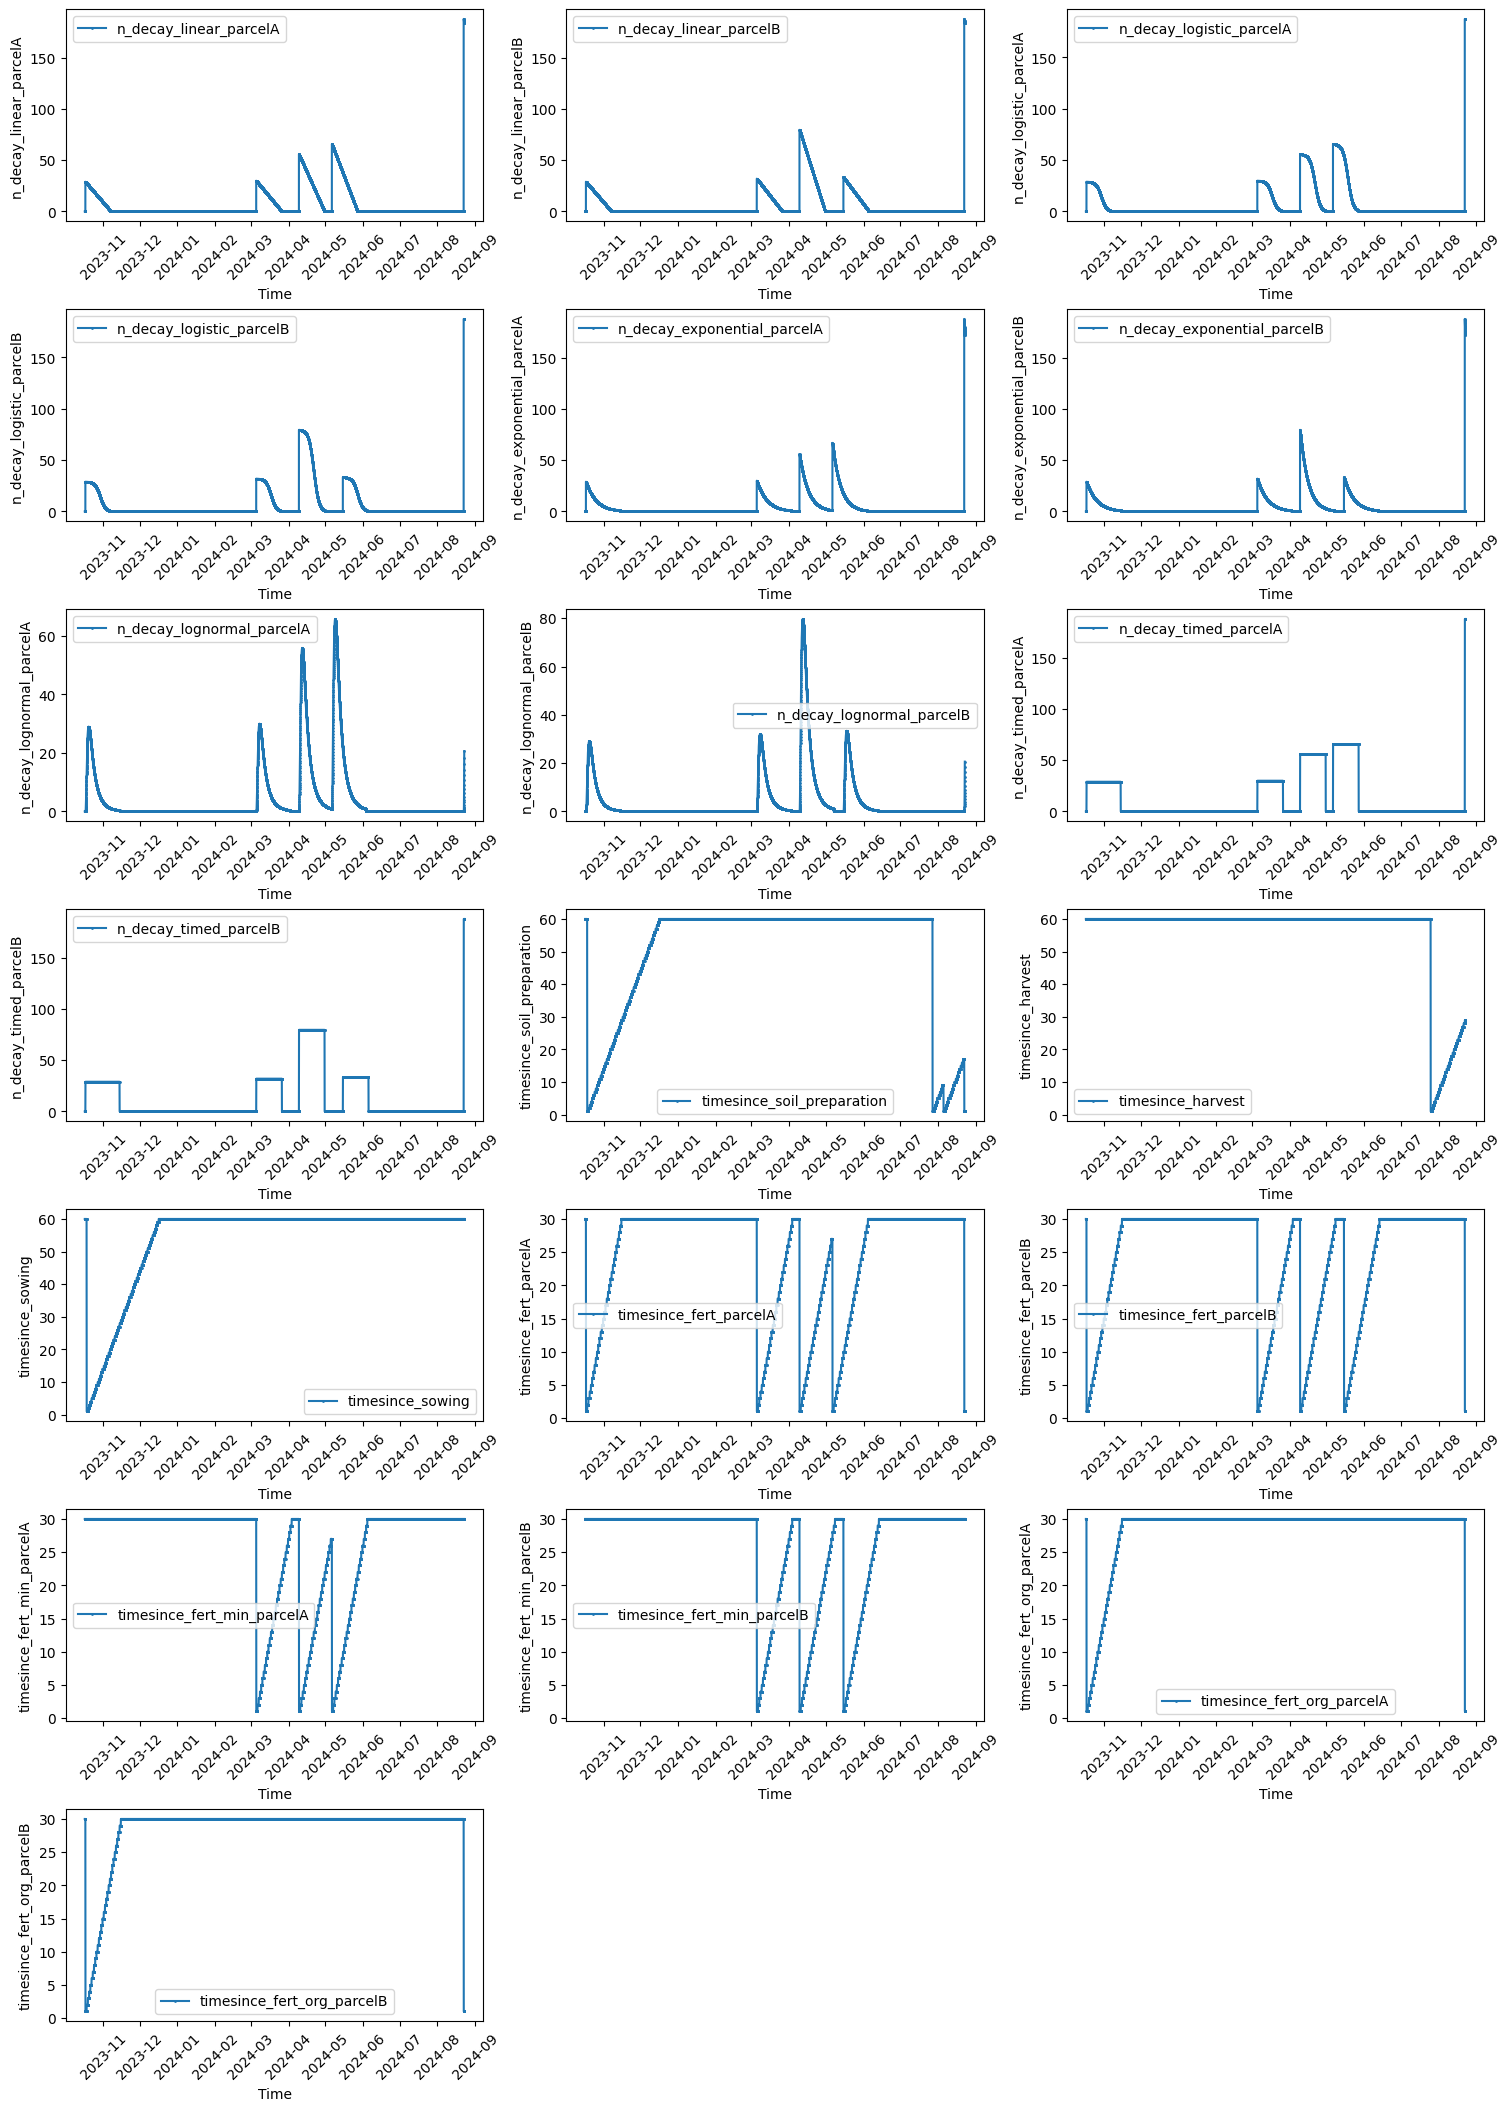

,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,60,60,60,30,30,30,30,30,30
2023-10-17 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,60,60,60,30,30,30,30,30,30
2023-10-17 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,60,60,60,30,30,30,30,30,30
2023-10-17 01:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,60,60,60,30,30,30,30,30,30
2023-10-17 02:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,60,60,60,30,30,30,30,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,184.456349,184.456349,187.286349,187.286349,174.585550,174.585550,12.443672,12.443672,188.0,188.0,1,29,60,1,1,30,30,1,1
2024-08-22 22:15:00,184.269841,184.269841,187.279204,187.279204,173.906660,173.906660,14.317380,14.317380,188.0,188.0,1,29,60,1,1,30,30,1,1
2024-08-22 22:45:00,184.083333,184.083333,187.271988,187.271988,173.230410,173.230410,16.309472,16.309472,188.0,188.0,1,29,60,1,1,30,30,1,1


In [6]:
management = load_parquet(filepath=r"../../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet")

# select subset of columns
prefix = ('n_decay', 'timesince', 'timed')
cols = [c for c in management.columns if c.startswith(prefix)]
management = management[cols]

# plots
plot_data_grid(management, ncols=3)

# show data
management

## CANOPY

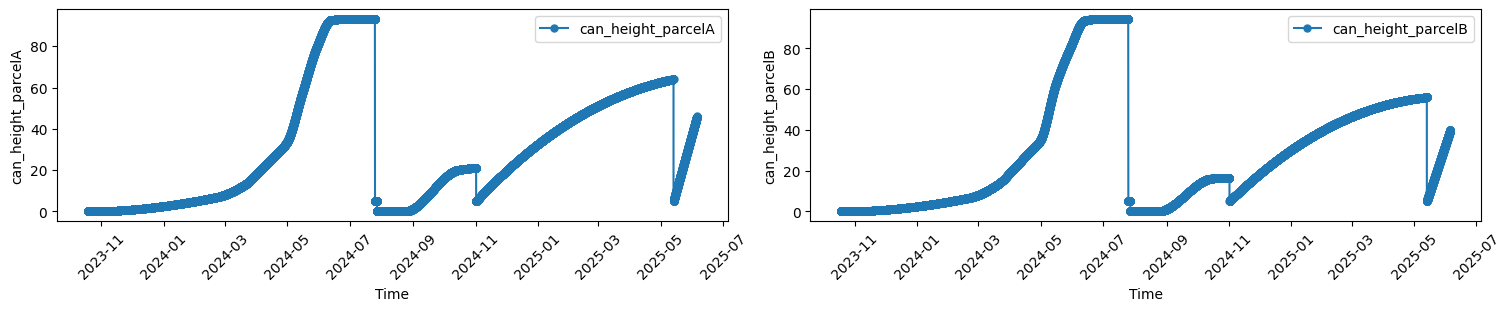

,can_height_parcelA,can_height_parcelB
TIMESTAMP_MIDDLE,,
2023-10-18 12:15:00,0.000000e+00,0.000000e+00
2023-10-18 12:45:00,2.190561e-07,2.045139e-07
2023-10-18 13:15:00,8.762039e-07,8.180423e-07
2023-10-18 13:45:00,1.971412e-06,1.840565e-06
2023-10-18 14:15:00,3.504651e-06,3.272063e-06
...,...,...
2025-06-05 10:15:00,4.585131e+01,3.987307e+01
2025-06-05 10:45:00,4.588849e+01,3.990481e+01
2025-06-05 11:15:00,4.592566e+01,3.993654e+01


In [7]:
vars_ = ["can_height"] # options you can add are 'LAI', 'can_height', 'biomass', 'cropN'
canopy = None
for var in vars_:
    df = pd.read_csv(DATA_DIR / "CANOPY" / f"02-{var}_model.csv")
    canopy = df if canopy is None else canopy.merge(df, on='TIMESTAMP_MIDDLE', how="outer")

canopy = canopy.sort_values('TIMESTAMP_MIDDLE')
canopy['TIMESTAMP_MIDDLE'] = pd.to_datetime(canopy['TIMESTAMP_MIDDLE'])
canopy.set_index('TIMESTAMP_MIDDLE', inplace=True)

canopy = canopy[[c for c in canopy if 'parcel' in c]]

# plots
plot_data_grid(canopy, ncols=2)

# show data
canopy

# MERGE DATA

## MERGE

In [8]:
df = pd.concat([fluxes, meteo, management, canopy], axis=1)

# Restrict to the dataset period (the canopy data cover the whole station record)
df = select_period(df, timestamp='middle')

select_period: kept 14928 of 28683 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)


## SANITIZE TIMESTAMP

In [9]:
# Remove duplicates, keep first
locs_duplicates = df.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
df = df[~locs_duplicates]

# Remove NaTs
locs_nats = df.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
df = df[~locs_nats]

# Sort timestamp index
df = df.sort_index(ascending=True)

df

Found duplicates in index: 0
Found NaTs in index: 0


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,timesince_fert_min_parcelA,timesince_fert_min_parcelB,timesince_fert_org_parcelA,timesince_fert_org_parcelB,can_height_parcelA,can_height_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,0.000000,0.000000,0.0,0.0,60.0,60.0,60.0,30.0,30.0,30.0,30.0,30.0,30.0,NaN,NaN
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,0.000000,0.000000,0.0,0.0,60.0,60.0,60.0,30.0,30.0,30.0,30.0,30.0,30.0,NaN,NaN
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.566667,0.0,0.0,...,0.000000,0.000000,0.0,0.0,60.0,60.0,60.0,30.0,30.0,30.0,30.0,30.0,30.0,NaN,NaN
2023-10-17 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.266667,0.0,0.0,...,0.000000,0.000000,0.0,0.0,60.0,60.0,60.0,30.0,30.0,30.0,30.0,30.0,30.0,NaN,NaN
2023-10-17 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.400000,0.0,0.0,...,0.000000,0.000000,0.0,0.0,60.0,60.0,60.0,30.0,30.0,30.0,30.0,30.0,30.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.48319,0.0,0.0,15.870000,0.0,0.0,...,12.443672,12.443672,188.0,188.0,1.0,29.0,60.0,1.0,1.0,30.0,30.0,1.0,1.0,0.0,0.0
2024-08-22 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.96792,0.0,0.0,15.160000,0.0,0.0,...,14.317380,14.317380,188.0,188.0,1.0,29.0,60.0,1.0,1.0,30.0,30.0,1.0,1.0,0.0,0.0
2024-08-22 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.14515,0.0,0.0,15.100000,0.0,0.0,...,16.309472,16.309472,188.0,188.0,1.0,29.0,60.0,1.0,1.0,30.0,30.0,1.0,1.0,0.0,0.0


In [10]:
df.columns

Index(['NEE_L3.3_CUT_16_QCF', 'NEE_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_84_QCF', 'NEE_L3.3_CUT_16_QCF0', 'NEE_L3.3_CUT_50_QCF0', 'NEE_L3.3_CUT_84_QCF0', 'parcel', 'parcel_certainty', 'trt', 'FC_RANDUNC_HF', 'SW_IN_POT', 'prec', 'ta', 'ppfd', 'sw_in', 'rh', 'timesince_prec', 'vpd', 'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_soil_preparation', 'timesince_harvest', 'timesince_sowing', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'timesince_fert_min_parcelA', 'timesince_fert_min_parcelB', 'timesince_fert_org_parcelA', 'timesince_fert_org_parcelB', 'can_height_parcelA', 'can_height_parcelB'], dtype='object')

# LAGGED VARIANTS

Variables for which lagged variants will be calculated:

In [11]:
# Define columns of interest
_list_lag_vars = [
    'NEE_L3.3_CUT_50_QCF_gfXGBoost',
    'GPP_NT_CUT_50_gfXG','RECO_NT_CUT_50_gfXG',
    'prec',
    'ta',
    'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 
    'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG'
]

_list_lag_vars = [c for c in df.columns if any([c.startswith(v) for v in _list_lag_vars])]

_list_lag_vars

['prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG']

Calculate the lagged variants

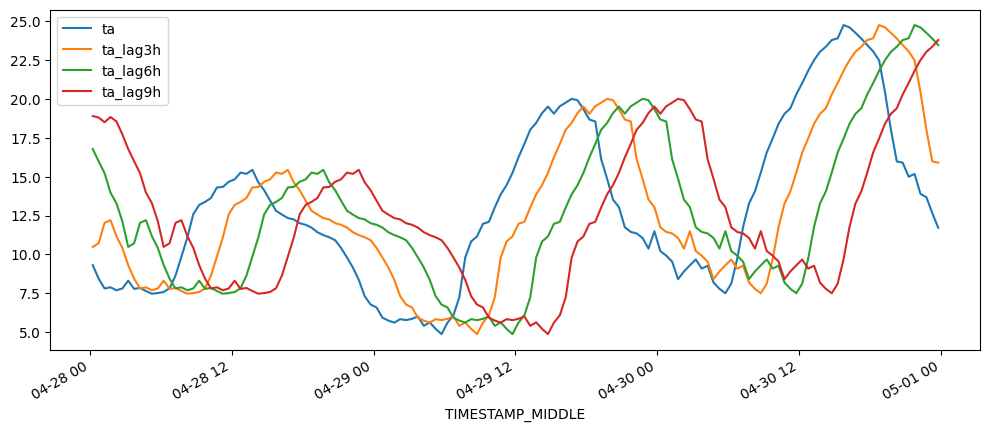

In [12]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Create lagged variants
for v in _list_lag_vars:
    for lag in intervals:
        lag_adjusted = int(lag/time_res)
        if lag_adjusted > 0:
            var_lag = f'{v}_lag{lag}h'
            df[var_lag] = df[v].shift(lag_adjusted)

# Plot the lag vars for TA
indat = df[[c for c in df.columns if c.startswith('ta')]]
indat = indat.loc['2024-04-28':'2024-04-30']
indat.plot(x_compat=True, figsize=(12, 5));

# ROLLING VARIANTS

Variables for which rolling variants will be calculated:

In [13]:
# Define columns of interest
_list_rolling_vars = [c for c in df.columns if c.startswith(tuple(_list_lag_vars))]
_list_rolling_vars

['prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'prec_lag3h',
 'prec_lag6h',
 'prec_lag9h',
 'ta_lag3h',
 'ta_lag6h',
 'ta_lag9h',
 'ts_0.05_gfXG_lag3h',
 'ts_0.05_gfXG_lag6h',
 'ts_0.05_gfXG_lag9h',
 'ts_0.15_gfXG_lag3h',
 'ts_0.15_gfXG_lag6h',
 'ts_0.15_gfXG_lag9h',
 'ts_0.3_gfXG_lag3h',
 'ts_0.3_gfXG_lag6h',
 'ts_0.3_gfXG_lag9h',
 'wfps_0.05_gfXG_lag3h',
 'wfps_0.05_gfXG_lag6h',
 'wfps_0.05_gfXG_lag9h',
 'wfps_0.15_gfXG_lag3h',
 'wfps_0.15_gfXG_lag6h',
 'wfps_0.15_gfXG_lag9h',
 'wfps_0.3_gfXG_lag3h',
 'wfps_0.3_gfXG_lag6h',
 'wfps_0.3_gfXG_lag9h']

Calculate the rolling variants

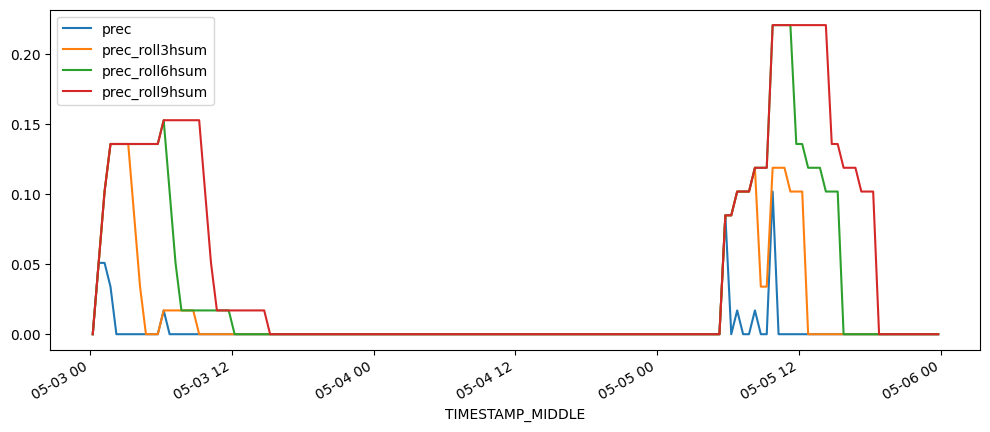

In [14]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Define the type of aggregations we will apply
aggtypes_default = ['mean']
aggtypes_sum = ['sum'] # for 'prec', 'GPP', 'Reco', 'NEE'


# Create rolling variants
for v in _list_rolling_vars:
    # Determine aggregation type
    aggtypes = aggtypes_sum if v.startswith(('prec', 'GPP', 'Reco', 'NEE')) else aggtypes_default
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            for agg in aggtypes:
                var_roll = f'{v}_roll{interval}h{agg}'
                df[var_roll] = df[v].rolling(interval_adjusted, min_periods=1).agg(agg)
                df = df.copy()

# Plot the lag vars for GPP
indat = df[[c for c in df.columns if c.startswith('prec') and 'lag' not in c]]
indat = indat.loc['2024-05-03':'2024-05-05']
indat.plot(x_compat=True, figsize=(12,5));

# RATE OF CHANGE

Used for WFPS and TS

In [15]:
# define columns of interest
_list_diff_vars = [col for col in df.columns if ('ts' in col or 'wfps' in col) and ('roll' not in col and 'lag' not in col)]

print(f'We calculate the rate of change for these variables: {_list_diff_vars}')

We calculate the rate of change for these variables: ['ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG']


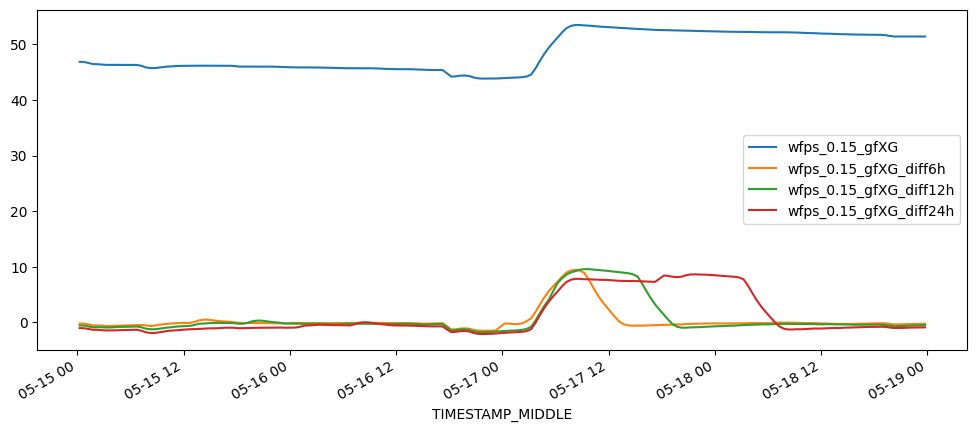

In [16]:
# Define interval of records for the difference calculation
intervals = [6, 12, 24] # in hours


# Time resolution of the dataframe
time_res = 0.5

# Create the variants
for v in _list_diff_vars:
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            var_diff = f'{v}_diff{interval}h'
            df[var_diff] = df[v].diff(periods=interval_adjusted)


# Plot the lag vars for wfps_0.15

indat = df[[c for c in df.columns if c.startswith('wfps_0.15') and 'lag' not in c and 'roll' not in c]]
indat = indat.loc['2024-05-15':'2024-05-18']
indat.plot(x_compat=True, figsize=(12, 5));

# MERGE PARCEL-SPECIFIC COLS

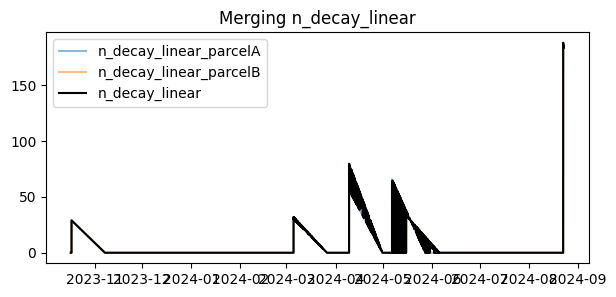

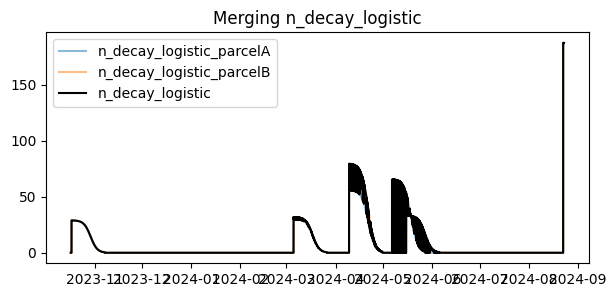

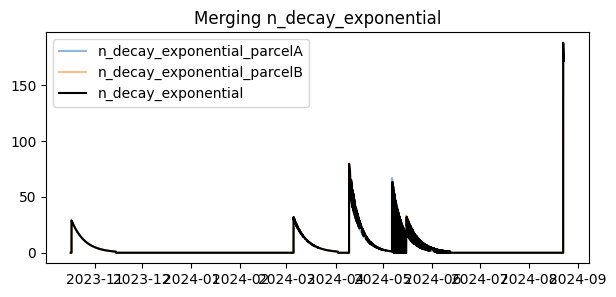

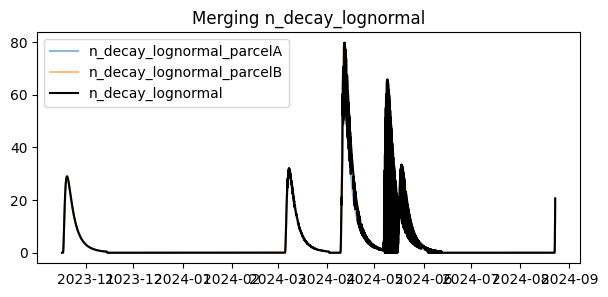

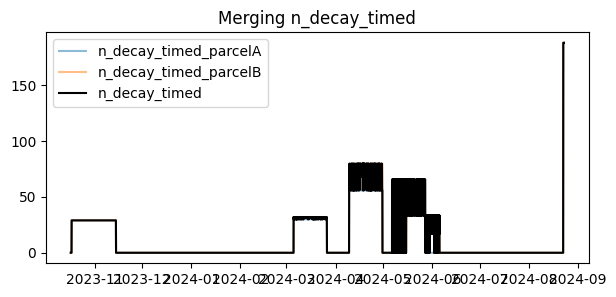

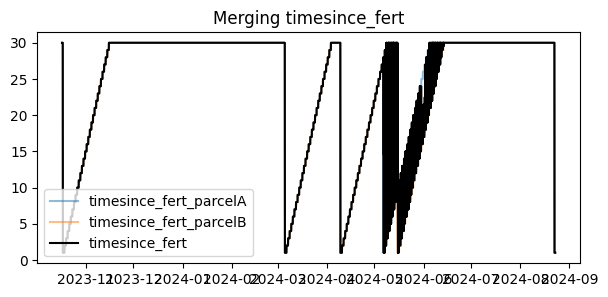

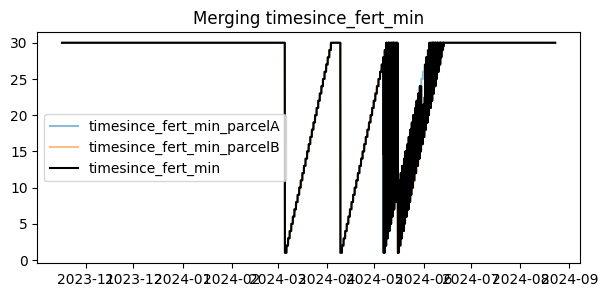

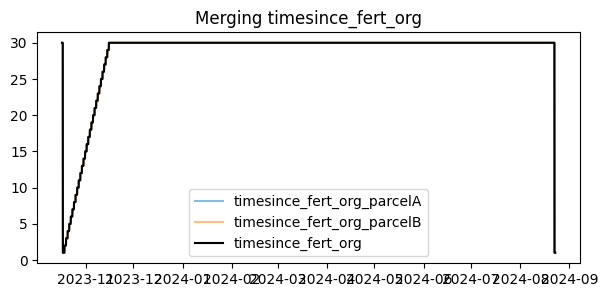

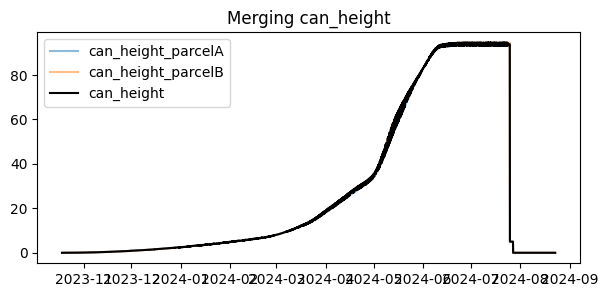

In [17]:
# Merge the split management in one column based on the parcel column
for colA in df.columns:
    if "_parcelA" in colA:
        base = colA.replace("_parcelA", "")
        colB = colA.replace("_parcelA", "_parcelB")
        if colB in df:
            avg_parcels = df[[colA, colB]].mean(axis=1)
            df[base] = np.select(
                [
                    df["parcel_certainty"].eq("uncertain"),  # mixed parcel contribution 
                    df["parcel"] == "A",
                    df["parcel"] == "B"
                ],
                [
                    avg_parcels,      # average of A and B when the contribution is mixed
                    df[colA],      # from A
                    df[colB]       # from B
                ],
                default=np.nan   # others → NaN
            )

            # ---- plot comparison before dropping ----
            plt.figure(figsize=(7, 3))
            plt.plot(df.index, df[colA], label=colA, alpha=0.5)
            plt.plot(df.index, df[colB], label=colB, alpha=0.5)
            plt.plot(df.index, df[base], label=base, alpha=1, color="black")
            plt.title(f"Merging {base}")
            plt.legend()

# ID COLUMN

In [18]:
df['id'] = range(0, len(df))
print("Added 'id' column to dataframe. It can be used as an index variable for gap-filling models.")

Added 'id' column to dataframe. It can be used as an index variable for gap-filling models.


# EXPORT DATA

## CHECK DATAFRAME

In [19]:
df

,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,0
2023-10-17 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,1
2023-10-17 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.566667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,2
2023-10-17 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.266667,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,3
2023-10-17 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.400000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.48319,0.0,0.0,15.870000,0.0,0.0,...,-0.926389,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,14923
2024-08-22 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.96792,0.0,0.0,15.160000,0.0,0.0,...,-0.895817,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,14924
2024-08-22 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.14515,0.0,0.0,15.100000,0.0,0.0,...,-0.886399,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,14925


Check what columns are contained in the final dataset

In [20]:
print(f'Dataframe contains {len(df.columns)} columns: {sorted(df.columns)}')

Dataframe contains 193 columns: ['FC_RANDUNC_HF', 'NEE_L3.3_CUT_16_QCF', 'NEE_L3.3_CUT_16_QCF0', 'NEE_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0', 'NEE_L3.3_CUT_84_QCF', 'NEE_L3.3_CUT_84_QCF0', 'SW_IN_POT', 'can_height', 'can_height_parcelA', 'can_height_parcelB', 'id', 'n_decay_exponential', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_linear', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_lognormal', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'parcel', 'parcel_certainty', 'ppfd', 'prec', 'prec_lag3h', 'prec_lag3h_roll3hsum', 'prec_lag3h_roll6hsum', 'prec_lag3h_roll9hsum', 'prec_lag6h', 'prec_lag6h_roll3hsum', 'prec_lag6h_roll6hsum', 'prec_lag6h_roll9hsum', 'prec_lag9h', 'prec_lag9h_roll3hsum', 'prec_lag9h_roll6hsum', 'prec_lag9h_roll9hsum', 'prec_roll3hsum', 'prec_roll6hsum', 'prec_roll9hsum

Check the timestamp

In [21]:
# Generate the complete timestamp range
start_date = df.index.min()
end_date = df.index.max()
complete_timestamp = pd.date_range(start=start_date, end=end_date, freq='30min')

# Compare the complete range with the dataframe's index
missing_timestamps = complete_timestamp.difference(df.index)
duplicate_timestamps = df.index[df.index.duplicated()]

# Output the duplicate and missing timestamps
if not duplicate_timestamps.empty:
    print("Duplicate Timestamps:")
    print(duplicate_timestamps)
else:
    print("No duplicate timestamps found.")

if not missing_timestamps.empty:
    print("Missing Timestamps:")
    print(missing_timestamps)
else:
    print("No missing timestamps found.")

# Check if the timestamp is complete and has no duplicates
if duplicate_timestamps.empty and missing_timestamps.empty:
    print("The timestamp index is complete and has no duplicates.")
else:
    print("The timestamp index has issues.")

No duplicate timestamps found.
No missing timestamps found.
The timestamp index is complete and has no duplicates.


## EXPORT

In [22]:
filename = "81.1.1_GapFillingDataset"
save_parquet(data=df, filename=filename)

Saved file 81.1.1_GapFillingDataset.parquet (0.718 seconds).


'81.1.1_GapFillingDataset.parquet'

# **End of notebook**

In [23]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-17 16:36:31
